In [116]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, losses, optimizers

from itertools import product

In [ ]:
from numpy.random import seed
import random
tf.config.experimental.enable_op_determinism()

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [45]:
def plot_categories_count(df,col):
    classVals, classCnts = np.unique(df[col], return_counts=True)
    plt.figure(figsize=(8,6))
    plt.bar(classVals, classCnts)
    plt.xlabel("category")
    plt.ylabel("samples")
    plt.title(f"{col} distribution")
    plt.show()

In [67]:
# funkcja do budowy modelu
def create_nn_model_softmax(x_train, output_class_number, neurons, dropout=0., optimizer=optimizers.Adam()):
    """
    :param x_train: data to conduct training
    :param output_class_number: number of output classes
    :param neurons: list of neurons in each hidden layer, list of integers
    :param dropout: dropout rate
    :param optimizer: optimizer names (string) from keras namespace
    :return: keras model object
    """
    # pusty model
    model = tf.keras.Sequential()
    # wejście
    model.add(layers.InputLayer(input_shape=(x_train.shape[1],)))
    # warstwy ukryte
    for neuron_layer in neurons:
        model.add(layers.Dense(neuron_layer, activation="relu", use_bias=True))
        model.add(layers.Dropout(dropout))
    # warstwa wyjściowa
    model.add(layers.Dense(output_class_number, activation="softmax"))
    # podsumowanie
    print(model.summary())
    # kompilujemy
    model.compile(
        optimizer = optimizer,
        loss = losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    # zwracamy model
    return model

### Import data

In [3]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [5]:
print(f"Shape of train: {train.shape}\nShape of test: {test.shape}")

Shape of train: (2000, 21)
Shape of test: (1000, 21)


### train EDA

In [6]:
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [8]:
train.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [10]:
for column in train.select_dtypes(include='int').columns:
    print(f"Unique values in {column}: {train[column].unique()}")
    print(f"Number of unique values in {column}: {train[column].nunique()}\n")

Unique values in battery_power: [ 842 1021  563 ... 1139 1467  858]
Number of unique values in battery_power: 1094

Unique values in blue: [0 1]
Number of unique values in blue: 2

Unique values in dual_sim: [0 1]
Number of unique values in dual_sim: 2

Unique values in fc: [ 1  0  2 13  3  4  5  7 11 12 16  6 15  8  9 10 18 17 14 19]
Number of unique values in fc: 20

Unique values in four_g: [0 1]
Number of unique values in four_g: 2

Unique values in int_memory: [ 7 53 41 10 44 22 24  9 33 17 52 46 13 23 49 19 39 47 38  8 57 51 21  5
 60 61  6 11 50 34 20 27 42 40 64 14 63 43 16 48 12 55 36 30 45 29 58 25
  3 54 15 37 31 32  4 18  2 56 26 35 59 28 62]
Number of unique values in int_memory: 63

Unique values in mobile_wt: [188 136 145 131 141 164 139 187 174  93 182 177 159 198 185 196 121 101
  81 156 199 114 111 132 143  96 200  88 150 107 100 157 160 119  87 152
 166 110 118 162 127 109 102 104 148 180 128 134 144 168 155 165  80 138
 142  90 197 172 116  85 163 178 171 103  83 14

In [29]:
categorical_columns = [column for column in train.select_dtypes(include='int').columns if train[column].nunique() == 2]
target_column = "price_range"
numerical_columns = [column for column in train.columns if column not in categorical_columns + [target_column]]

if train[numerical_columns + categorical_columns + [target_column]].shape[1] == train.shape[1]:
    print("All columns were assigned to a data type list")
else:
    missing_columns = [column for column in train.columns if column not in numerical_columns + categorical_columns + [target_column]]
    print(f"Missing columns: {missing_columns}")

All columns were assigned to a data type list


### test EDA

In [23]:
test.head()

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [20]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1000 non-null   int64  
 1   battery_power  1000 non-null   int64  
 2   blue           1000 non-null   int64  
 3   clock_speed    1000 non-null   float64
 4   dual_sim       1000 non-null   int64  
 5   fc             1000 non-null   int64  
 6   four_g         1000 non-null   int64  
 7   int_memory     1000 non-null   int64  
 8   m_dep          1000 non-null   float64
 9   mobile_wt      1000 non-null   int64  
 10  n_cores        1000 non-null   int64  
 11  pc             1000 non-null   int64  
 12  px_height      1000 non-null   int64  
 13  px_width       1000 non-null   int64  
 14  ram            1000 non-null   int64  
 15  sc_h           1000 non-null   int64  
 16  sc_w           1000 non-null   int64  
 17  talk_time      1000 non-null   int64  
 18  three_g  

In [21]:
print("Columns missing in test set: ", [column for column in test.columns if column not in train.columns])

Columns missing in test set:  ['id']


In [22]:
print("Columns missing in train set: ", [column for column in train.columns if column not in test.columns])

Columns missing in train set:  ['price_range']


I don't need the 'id' column, so I'm deleting it. 

In [24]:
test = test.drop("id", axis=1)

Scaling the data

In [34]:
scaler = MinMaxScaler()

train[numerical_columns] = scaler.fit_transform(train[numerical_columns])
test[numerical_columns] = scaler.transform(test[numerical_columns])

In [35]:
train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,0.227789,0,0.68,0,0.052632,0,0.080645,0.555556,0.900000,0.142857,...,0.010204,0.170895,0.612774,0.285714,0.388889,0.944444,0,0,1,1
1,0.347361,1,0.00,1,0.000000,1,0.822581,0.666667,0.466667,0.285714,...,0.461735,0.993324,0.634687,0.857143,0.166667,0.277778,1,1,0,2
2,0.041416,1,0.00,1,0.105263,1,0.629032,0.888889,0.541667,0.571429,...,0.644388,0.811749,0.627205,0.428571,0.111111,0.388889,1,1,0,2
3,0.076152,1,0.80,0,0.000000,0,0.129032,0.777778,0.425000,0.714286,...,0.620408,0.858478,0.671566,0.785714,0.444444,0.500000,1,0,0,2
4,0.881764,1,0.28,0,0.684211,1,0.677419,0.555556,0.508333,0.142857,...,0.616327,0.475300,0.308658,0.214286,0.111111,0.722222,1,1,0,1


In [36]:
test.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,0.362057,1,0.52,1,0.736842,0,0.048387,0.000000,0.941667,0.285714,0.8,0.115306,0.608812,0.860502,0.500000,0.388889,0.000000,0,1,0
1,0.227121,1,0.00,1,0.210526,1,0.951613,0.777778,0.925000,0.571429,0.6,0.380612,0.238318,0.972475,0.071429,0.000000,0.277778,1,0,0
2,0.872411,1,0.92,0,0.052632,0,0.403226,0.888889,0.883333,0.285714,0.2,0.647959,0.578104,0.571887,0.857143,0.555556,0.444444,0,1,1
3,0.698063,0,0.00,1,0.947368,1,0.370968,0.444444,0.133333,1.000000,1.0,0.150510,0.835781,0.971940,0.357143,0.000000,0.277778,1,1,0
4,0.623246,0,0.36,0,0.578947,1,0.758065,0.444444,0.233333,0.714286,0.9,0.382143,0.206943,0.405398,0.714286,0.444444,0.277778,1,0,1


Boxplots

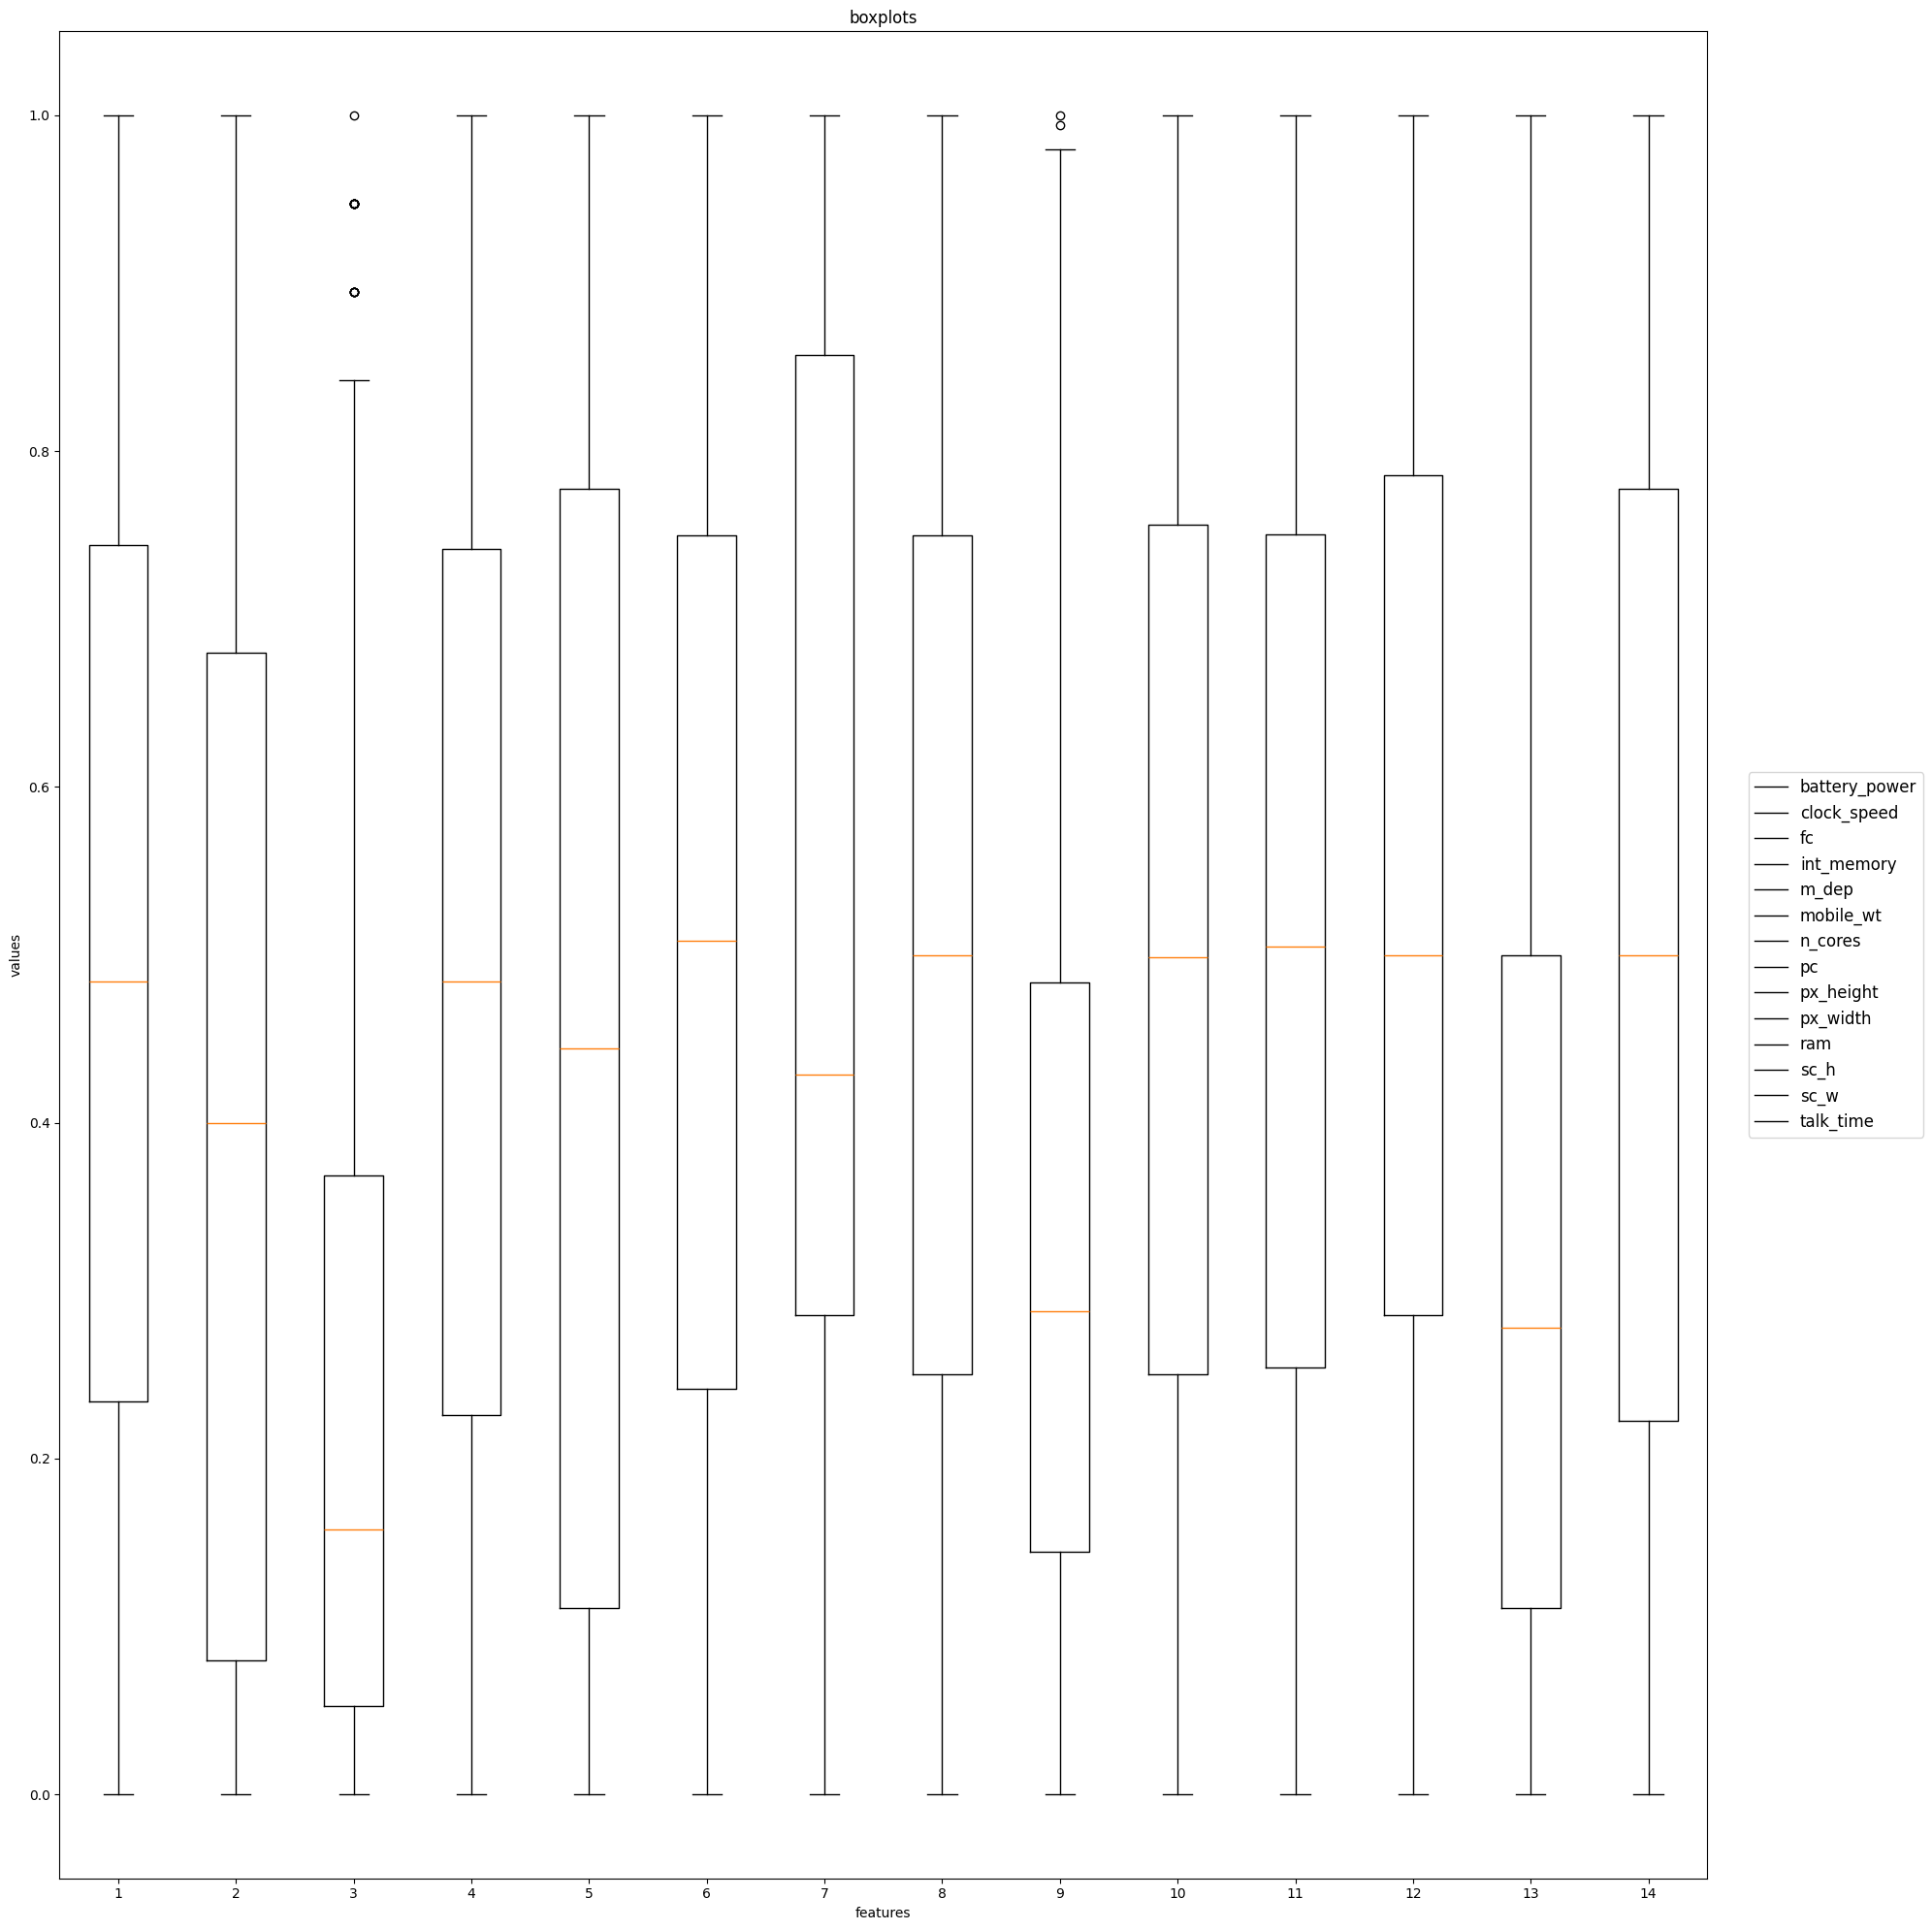

In [44]:
fig = plt.figure(figsize=(20,20))
plt.boxplot(train[numerical_columns])
plt.xlabel("features")
plt.ylabel("values")
plt.title("boxplots")
plt.legend(
    numerical_columns,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12
)
plt.tight_layout()
plt.show()

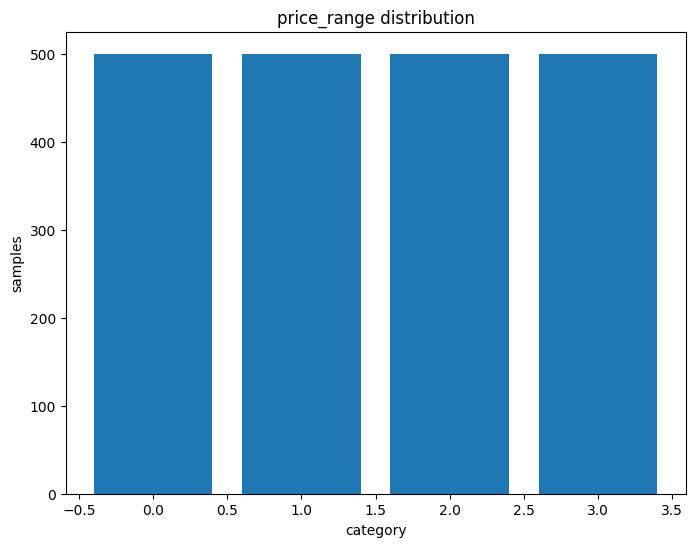

In [46]:
plot_categories_count(train, target_column)

In [38]:
X_train, X_val, y_train, y_val = train_test_split(train.drop(target_column,axis=1), train[target_column], test_size = 0.3, random_state = 1)

print(f"Shape of X_train: {X_train.shape}\nShape of X_val: {X_val.shape}\nShape of y_train: {y_train.shape}\nShape of y_val: {y_val.shape}")

Shape of X_train: (1400, 20)
Shape of X_val: (600, 20)
Shape of y_train: (1400,)
Shape of y_val: (600,)


### Models

In [69]:
model_2_layers_small = create_nn_model_softmax(
    X_train,
    output_class_number=4,
    neurons=[16, 8],
    dropout=0.,
    optimizer=optimizers.Adam(learning_rate=0.001)
)

model_2_layer_medium = create_nn_model_softmax(
    X_train,
    output_class_number=4,
    neurons=[32,16],
    dropout=0.,
    optimizer=optimizers.Adam(learning_rate=0.001)
)

model_2_layer_big = create_nn_model_softmax(
    X_train,
    output_class_number=4,
    neurons=[64, 32],
    dropout=0.,
    optimizer=optimizers.Adam(learning_rate=0.001)
)

c:\Users\Marki\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 508 (1.98 KB)

 Trainable params: 508 (1.98 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,556 (13.89 KB)

 Trainable params: 3,556 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

None


In [82]:
models = [model_2_layers_small, model_2_layer_medium, model_2_layer_big]
results = []
models_name = ["small", "medium", "big"]

In [83]:
batch_size = 50
epochs = 200

for model in models:
    tmp_results = model.fit(
        x=X_train,
        y=y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
        validation_data=(X_val, y_val)
    )
    results.append(tmp_results)


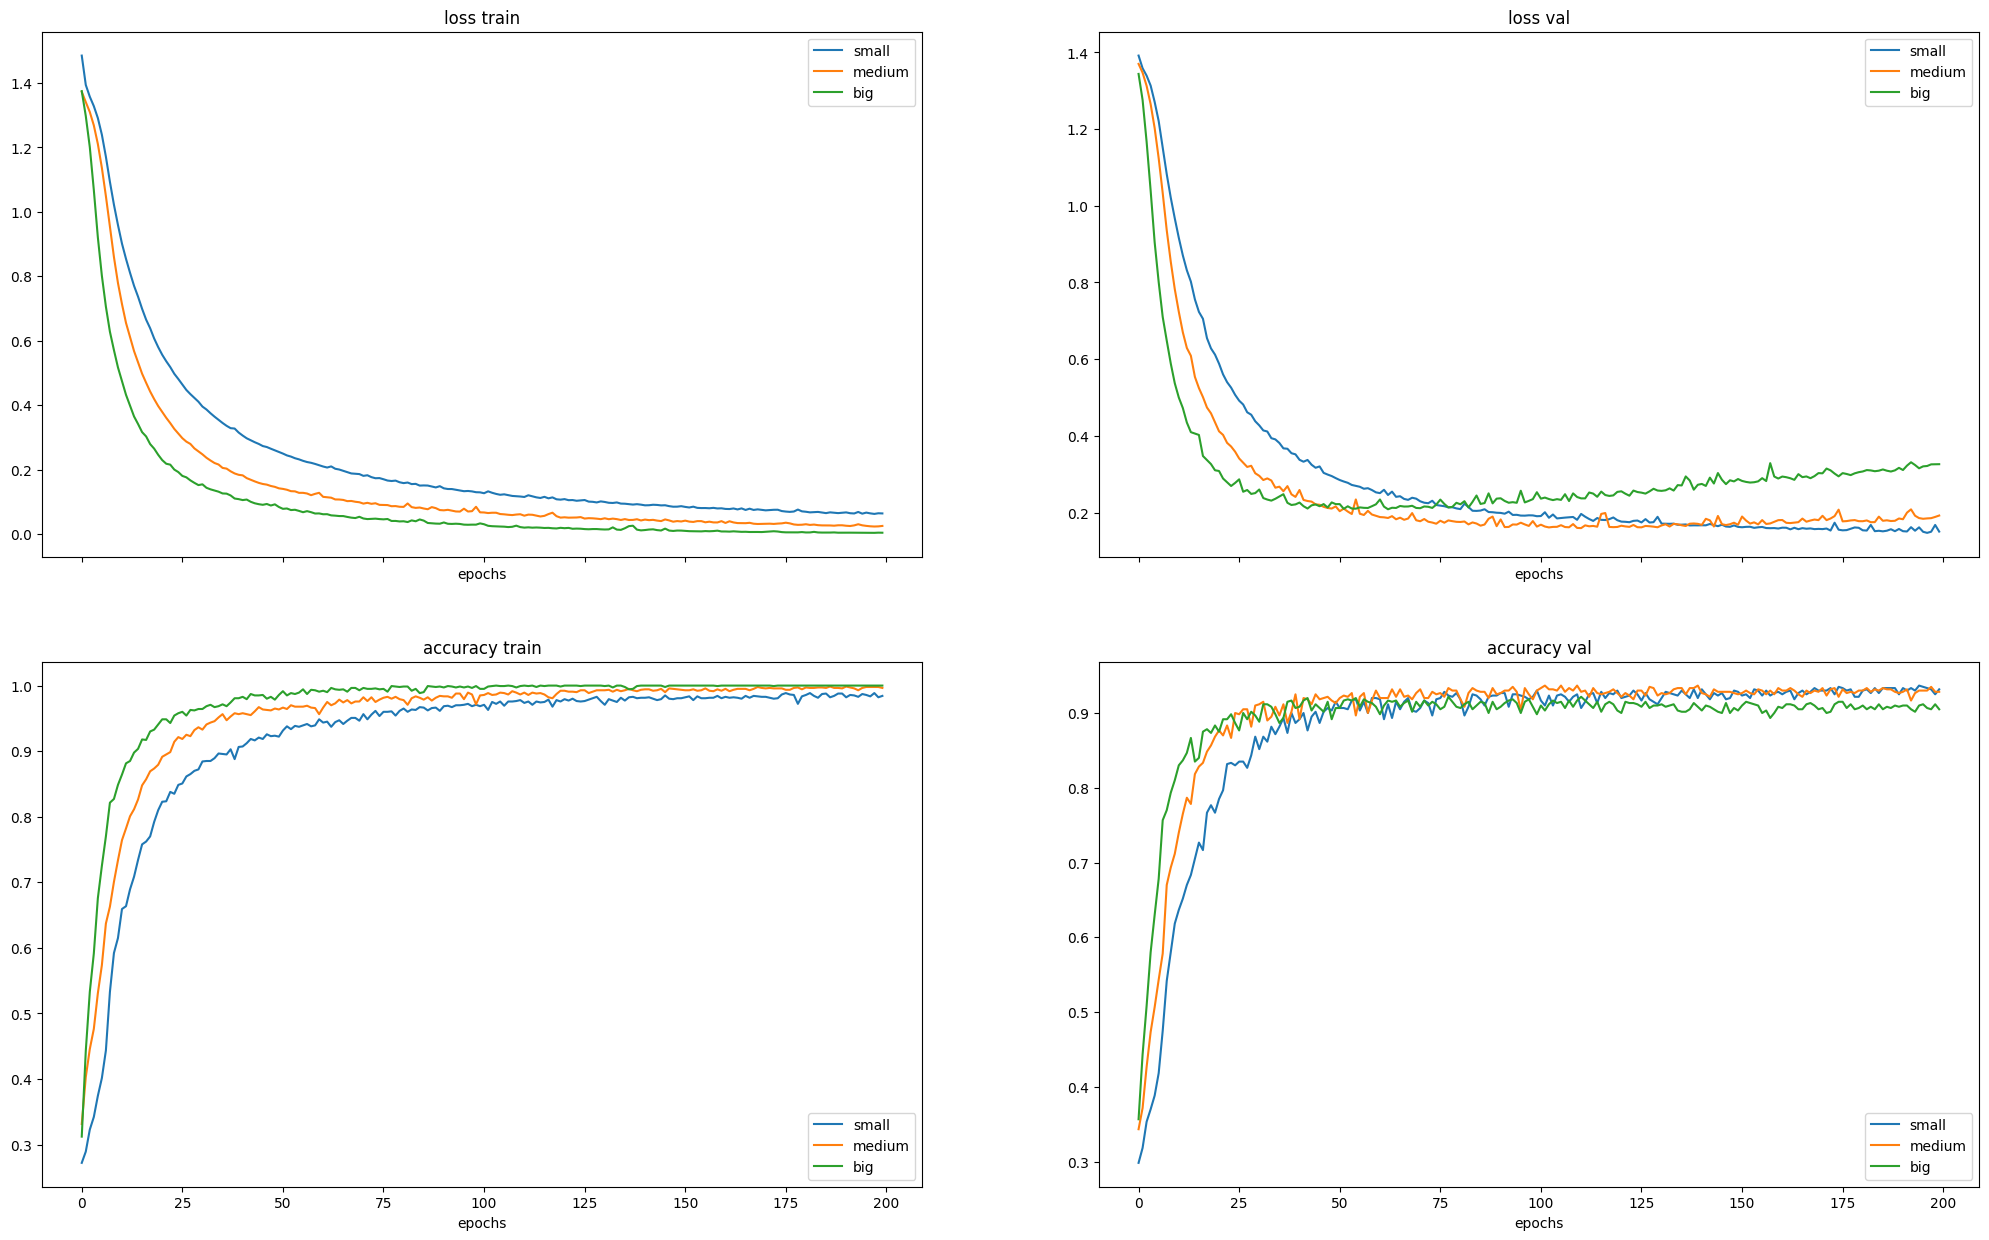

In [102]:
fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(25,15),
    sharex=True
)

for i in range(len(models)):
    # loss and accuracy charts
    ax[0,0].plot(results[i].history["loss"])
    ax[1,0].plot(results[i].history["accuracy"])
    ax[0,1].plot(results[i].history["val_loss"])
    ax[1,1].plot(results[i].history["val_accuracy"])
    
    # legends and titles
    # if i >= (len(results)-1):
    for k in itertools.product(range(2),range(2)):
        if k[0] == 0:
            chart_name_1 = "loss"
        else:
            chart_name_1 = "accuracy"
        if k[1] == 0:
            chart_name_2 ="train"
        else:
            chart_name_2 ="val"

        chart_name = chart_name_1 + " " + chart_name_2
    
        ax[k[0],k[1]].set_title(chart_name)
        ax[k[0],k[1]].legend(models_name)
        ax[k[0],k[1]].set_xlabel("epochs")



In [114]:
np.array(results[0].history["loss"]).argmin()

197

The big model after 50 epochs is overfitted. The small model achieved the smallest loss after 197 epochs.

In [125]:
y_val_pred = model_2_layers_small.predict(X_val)
print(classification_report(y_val, y_val_pred.argmax(axis=1)))
print(confusion_matrix(y_val, y_val_pred.argmax(axis=1)))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       135
           1       0.94      0.91      0.93       149
           2       0.89      0.90      0.90       168
           3       0.92      0.95      0.94       148

    accuracy                           0.93       600
   macro avg       0.93      0.93      0.93       600
weighted avg       0.93      0.93      0.93       600

[[131   4   0   0]
 [  2 136  11   0]
 [  0   5 151  12]
 [  0   0   7 141]]
